In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

In [2]:
df = pd.read_csv('tasks 2\\ebay_movies_and_tv.csv')

In [119]:
#remove emojis

df=df.astype(str).apply(lambda x: x.str.encode('ascii', 'ignore').str.decode('ascii'))

In [3]:
df.head(15)

,Title,Subtitle,Price,Shipping,Location,Watch Count,Seller Info,Link,Image URL
0,Studio Ghibli: Special Edition Collection 26 M...,Brand New · DVD · Movies,$33.90,+$28.06 delivery,from United States,NaN,michaelflory_62 (290) 99%,https://www.ebay.com/itm/135388704460,https://i.ebayimg.com/images/g/ilQAAOSwnLFnPV2...
1,prey 2022 Movie Blu ray BD Quick Free Shipping,Brand New · Blu-ray · Prey,$12.99,Free International Shipping,from China,NaN,luorongm4291955 (248) 88.3%,https://www.ebay.com/itm/205169633986,https://i.ebayimg.com/images/g/3RkAAOSwsk1l3x1...
2,Asian School Girls (DVD),Another great item from Rarewaves | Free UK de...,$10.49,+$3.70 delivery,from United Kingdom,NaN,"rarewaves-outlet (1,321,369) 98%",https://www.ebay.com/itm/356347156179,https://i.ebayimg.com/images/g/CV0AAOSw-v1nngA...
3,"New Silo Season 1-2 (DVD, 6-Disc) Box Set Seal...",New (Other) · DVD · New,$22.99,Free International Shipping,from United States,NaN,bayrfa-35 (23) 100%,https://www.ebay.com/itm/405532499908,https://i.ebayimg.com/images/g/~7cAAOSwUxlnqHi...
4,And Just Like That...: The Complete Second Sea...,Another great item from Rarewaves | Free UK de...,$11.07,+$3.70 delivery,from United Kingdom,NaN,"rarewaves-outlet (1,321,369) 98%",https://www.ebay.com/itm/305592604460,https://i.ebayimg.com/images/g/8fUAAOSwx3ZnNlj...
5,Dogma (DVD),Another great item from Rarewaves | Free UK de...,$9.62,+$3.70 delivery,from United Kingdom,NaN,"rarewaves-outlet (1,321,369) 98%",https://www.ebay.com/itm/305027924784,https://i.ebayimg.com/images/g/5VoAAeSwWGlnpRT...
6,The Beekeeper (DVD) Jason Statham Jeremy Irons...,Another great item from Rarewaves | Free UK de...,$11.65,+$3.70 delivery,from United Kingdom,NaN,"rarewaves-outlet (1,321,369) 98%",https://www.ebay.com/itm/305533810526,https://i.ebayimg.com/images/g/0z0AAOSw2l9mLAL...
7,Wild At Heart 2005 (DVD),Another great item from Rarewaves | Free UK de...,$10.40,+$3.70 delivery,from United Kingdom,NaN,"rarewaves-outlet (1,321,369) 98%",https://www.ebay.com/itm/356444510204,https://i.ebayimg.com/images/g/obUAAOSwDUhnfSs...
8,Furiosa: A Mad Max Saga (DVD),Another great item from Rarewaves | Free UK de...,$10.51,+$3.70 delivery,from United Kingdom,NaN,"rarewaves-outlet (1,321,369) 98%",https://www.ebay.com/itm/305624818536,https://i.ebayimg.com/images/g/doMAAOSwvdRmvxZ...
9,Twisters (4K UHD Blu-ray),Another great item from Rarewaves | Free UK de...,$19.42,+$3.70 delivery,from United Kingdom,NaN,"rarewaves-outlet (1,321,369) 98%",https://www.ebay.com/itm/305712203778,https://i.ebayimg.com/images/g/2jMAAOSwVABnT5A...


In [4]:
# have all columns names saved in lower case
df.columns = df.columns.str.lower()

In [5]:
# rename a column to add the currency in the shipping and the price column
df.rename(columns={"shipping": "shipping+deliveryfee$$"}, inplace=True)
df.rename(columns={"price": "price$$"}, inplace=True)

# rename the origin location column to show this is where the package is from
df.rename(columns={"location": "origin_location"}, inplace=True)

In [7]:
# # removing dollar sign 
df["price$$"] = df["price$$"].str.replace("$", "", regex=False)
df["shipping+deliveryfee$$"] = df["shipping+deliveryfee$$"].str.replace("$", "", regex=False)
df["price$$"] = df["price$$"].str.replace(",", "", regex=False)
df["shipping+deliveryfee$$"] = df["shipping+deliveryfee$$"].str.replace(",", "", regex=False)
df["shipping+deliveryfee$$"] = df["shipping+deliveryfee$$"].str.replace("+", "", regex=False)
df["shipping+deliveryfee$$"] = df["shipping+deliveryfee$$"].str.replace(" delivery", "", regex=False)
df["origin_location"] = df["origin_location"].str.replace("from ", "", regex=False)
df["watch count"] = df["watch count"].str.replace("+", "", regex=False)
df["watch count"] = df["watch count"].str.replace(" watchers", "", regex=False)

In [9]:
# check duplicates in df
df.duplicated().sum()

# drop all duplicates in the dataset
df.drop_duplicates(inplace=True)

In [8]:
df.rename(columns={"location": "origin_location"}, inplace=True)


In [10]:
# delete specific values from all rows in the origin location column
df["origin_location"] = df["origin_location"].str.replace("from ", "", regex=True)

In [11]:
# Function to check and replace range with mean
def replace_range_with_mean(value):
    # Check if the value matches the range format (e.g., "23.99 to 92.99")
    match = re.match(r"([\d.]+)to([\d.]+)", value)
    
    if match:
        # Extract the two numbers
        num1 = float(match.group(1))
        num2 = float(match.group(2))
        
        # Calculate the mean of the two numbers
        mean_value = (num1 + num2) / 2
        
        # Return the mean value as a string with 2 decimal points
        return f"{mean_value:.2f}"
    
    # Return the value unchanged if it is not a range
    return value

# Apply the function to the 'price' column
df["price$$"] = df["price$$"].apply(replace_range_with_mean)



In [12]:
#replace a free international shipping with a zero
df["shipping+deliveryfee$$"] = df["shipping+deliveryfee$$"].replace("Free International Shipping", "0")
df["shipping+deliveryfee$$"] = df["shipping+deliveryfee$$"].replace("Shipping not specified", "0")



In [15]:
df.dtypes

title                      object
subtitle                   object
price$$                   float64
shipping+deliveryfee$$    float64
origin_location            object
watch count               float64
seller info                object
link                       object
image url                  object
dtype: object

In [14]:
# # change dtype of price and shipping+deliveryfee columns to float
df["price$$"] = df["price$$"].astype(float)
df["watch count"] = df["watch count"].astype(float)
df["shipping+deliveryfee$$"] = df["shipping+deliveryfee$$"].astype(float)

In [17]:
df['shipping+deliveryfee$$'].describe()

count    8131.000000
mean       18.526256
std        14.143875
min         0.000000
25%         3.700000
50%        22.940000
75%        27.365000
max       206.940000
Name: shipping+deliveryfee$$, dtype: float64

In [18]:
# total number of rows with nan values in the dataset
totaln = df.isna().sum()

# total number of rows in the dataset
totalt = df.shape[0]
print(totalt / totaln)

title                          inf
subtitle                       inf
price$$                        inf
shipping+deliveryfee$$         inf
origin_location                inf
watch count               1.142476
seller info                    inf
link                           inf
image url                      inf
dtype: float64


In [19]:
# replace NaN values with zero in watch count column
df["watch count"] = df["watch count"].fillna(0)

{'whiskers': [<matplotlib.lines.Line2D at 0x29741559450>,
 'caps': [<matplotlib.lines.Line2D at 0x297417c1810>,
 'boxes': [<matplotlib.lines.Line2D at 0x2974155ae90>],
 'medians': [<matplotlib.lines.Line2D at 0x297417c1a90>],
 'fliers': [<matplotlib.lines.Line2D at 0x297417c1bd0>],
 'means': []}

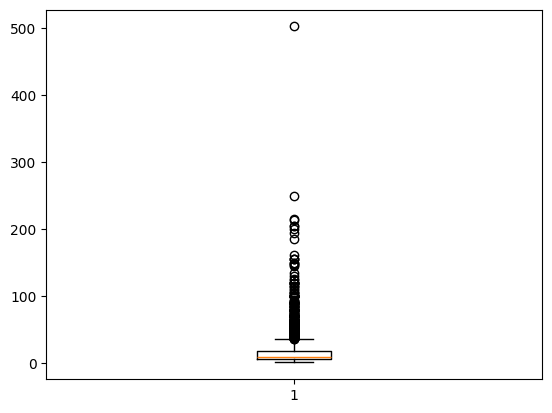

In [21]:
# draw a boxplot to show the distribution of the price column
plt.boxplot(df["price$$"])

In [42]:
df['price$$'].describe()

count    8131.000000
mean       14.155093
std        16.238069
min         0.990000
25%         5.590000
50%         9.410000
75%        17.990000
max       502.150000
Name: price$$, dtype: float64

In [26]:
# return all those columns and rows wheer price is greater than 1000    
df[df["price$$"] > 200]

,title,subtitle,price$$,shipping+deliveryfee$$,origin_location,watch count,seller info,link,image url
1440,Downunder Horsemanship 7 Courses 65 DVD Bundle...,New (Other) · DVD,212.93,0.00,United States,0.0,andbog-33 (227) 100%,https://www.ebay.com/itm/364840968956,https://i.ebayimg.com/images/g/bo0AAOSwKJFm~cL...
1936,New Identity V STAGE Episode 4 Phantom of The ...,Brand New · Blu-ray · Identity,215.00,40.00,Japan,0.0,"kyubey11 (18,497) 100%",https://www.ebay.com/itm/203834237719,https://i.ebayimg.com/images/g/HkIAAOSwGK5nZWb...
4558,"BLACK SASH , CERTIFICATE & 7 DVDS INCLUDED HOM...",New (Other) · DVD · Kung Fu,205.00,44.00,United States,10.0,quickship-kungfu (32) 100%,https://www.ebay.com/itm/126807483188,https://i.ebayimg.com/images/g/7Y0AAOSw6uZm9Eo...
4561,"BLACK SASH , CERTIFICATE & 7 DVDS INCLUDED HOM...",New (Other) · DVD · Kung Fu,205.00,44.00,United States,10.0,quickship-kungfu (32) 100%,https://www.ebay.com/itm/126807483188,https://i.ebayimg.com/images/g/7Y0AAOSw6uZm9Eo...
5058,One Piece Episodes 1 - 1096 ALL ENGLISH DUBBED...,Brand New · DVD · One Piece (2017 TV series),248.99,103.14,United States,0.0,"southwindelectronics (3,659) 99.4%",https://www.ebay.com/itm/275441238422,https://i.ebayimg.com/images/g/ehQAAOSwDOtncO6...
6480,GREAT BRITISH RAILWAY JOURNEYS Series 1 - 14 2...,Brand New · DVD,502.15,43.93,Australia,1.0,"melbournebargains2001 (5,025) 100%",https://www.ebay.com/itm/275387261291,https://i.ebayimg.com/images/g/RRAAAOSwLRFmACE...


In [23]:
df['shipping+deliveryfee$$'].describe()

count    8131.000000
mean       18.526256
std        14.143875
min         0.000000
25%         3.700000
50%        22.940000
75%        27.365000
max       206.940000
Name: shipping+deliveryfee$$, dtype: float64

{'whiskers': [<matplotlib.lines.Line2D at 0x297415a6850>,
 'caps': [<matplotlib.lines.Line2D at 0x297415a6ad0>,
 'boxes': [<matplotlib.lines.Line2D at 0x297415a6710>],
 'medians': [<matplotlib.lines.Line2D at 0x297415a6d50>],
 'fliers': [<matplotlib.lines.Line2D at 0x297415a6e90>],
 'means': []}

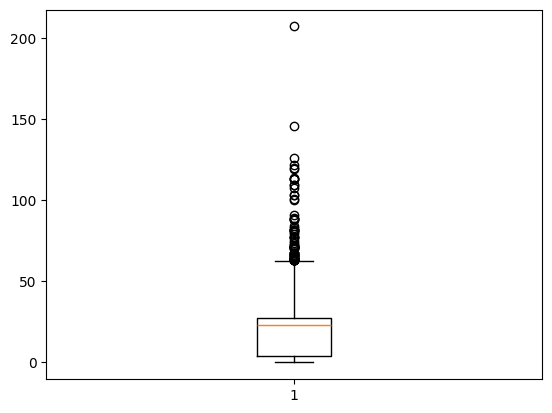

In [24]:
plt.boxplot(df["shipping+deliveryfee$$"])

In [28]:
# return all those columns and rows wheer price is greater than 1000    
df[df["shipping+deliveryfee$$"] > 100]

,title,subtitle,price$$,shipping+deliveryfee$$,origin_location,watch count,seller info,link,image url
28,80 Wholesale lot dvd movies assorted bulk Free...,Pre-Owned · DVD,34.99,206.94,United States,0.0,"secondspindisk (73,242) 99.1%",https://www.ebay.com/itm/145665733309,https://i.ebayimg.com/images/g/tHIAAOSwjX9l8wG...
281,Kids Childrens DVD Lot Huge Pick Choose You Ow...,Pre-Owned,2.49,109.22,United States,0.0,totally_rad_movies (860) 99.8%,https://www.ebay.com/itm/166763444374,https://i.ebayimg.com/images/g/uh8AAOSwpdtmQ02...
751,30 Wholesale DVD lot movies assorted bulk Free...,Pre-Owned · DVD,19.99,113.17,United States,0.0,"dvdworldwide2012 (12,535) 98.6%",https://www.ebay.com/itm/326193693255,https://i.ebayimg.com/images/g/Hb4AAOSw9HRmT19...
1434,Blu Ray Movie Lot Sale Pick and Choose Action ...,Use (Add to Cart) For Combined Shipping,5.49,109.22,United States,0.0,totally_rad_movies (860) 99.8%,https://www.ebay.com/itm/166941803407,https://i.ebayimg.com/images/g/cS8AAOSwW8xmy4V...
2991,Beverly Hills 90210: Complete Series DVD Yearb...,Pre-Owned · DVD · 90210,36.00,126.00,United States,15.0,"erka-4097 (2,782) 99.6%",https://www.ebay.com/itm/356501176438,https://i.ebayimg.com/images/g/qhwAAOSwPX5nk~J...
3162,Poldark: The Complete Series Seasons 1-5 DVD R...,Brand New · DVD,23.60,113.28,United States,11.0,"myteri1 (1,605) 98.8%",https://www.ebay.com/itm/387901939574,https://i.ebayimg.com/images/g/YUQAAOSwVfxnY-9...
3403,Movie & TV Series Box Sets - DVD & Blu Ray,Pre-Owned,5.45,100.51,United States,5.0,campfire_creativity (841) 100%,https://www.ebay.com/itm/395596714420,https://i.ebayimg.com/images/g/NUQAAOSwJyVmvWK...
3757,Orange is the New Black DVD complete Series Co...,Brand New · DVD · Orange Is the New Black,24.29,113.30,United States,2.0,evg_sales_18 (918) 96.9%,https://www.ebay.com/itm/205274119920,https://i.ebayimg.com/images/g/WksAAOSwii1nprS...
4653,Orange is the New Black DVD complete Series Co...,Brand New · DVD · Orange Is the New Black,25.60,119.47,United States,1.0,"merzy05mar05 (1,592) 100%",https://www.ebay.com/itm/296978454317,https://i.ebayimg.com/images/g/-TIAAOSwC0Vnna8...
5058,One Piece Episodes 1 - 1096 ALL ENGLISH DUBBED...,Brand New · DVD · One Piece (2017 TV series),248.99,103.14,United States,0.0,"southwindelectronics (3,659) 99.4%",https://www.ebay.com/itm/275441238422,https://i.ebayimg.com/images/g/ehQAAOSwDOtncO6...


In [29]:
# return all those columns and rows wheer shipping+deliveryfee is greater than price    
df[df["shipping+deliveryfee$$"] > df["price$$"]]   


,title,subtitle,price$$,shipping+deliveryfee$$,origin_location,watch count,seller info,link,image url
28,80 Wholesale lot dvd movies assorted bulk Free...,Pre-Owned · DVD,34.99,206.94,United States,0.0,"secondspindisk (73,242) 99.1%",https://www.ebay.com/itm/145665733309,https://i.ebayimg.com/images/g/tHIAAOSwjX9l8wG...
30,"Valentine [Collector's Edition, Blu-ray]",Brand New,22.99,27.74,United States,19.0,shoutfactory (506) 99.8%,https://www.ebay.com/itm/235584466707,https://i.ebayimg.com/images/g/pb8AAOSw-MFmVht...
37,"Me Before You DVD (2016) Emilia Clarke, Sharro...",Great Prices & Quality from musicMagpie. 10m+ ...,3.08,3.09,United Kingdom,0.0,"musicmagpie (12,753,438) 99.3%",https://www.ebay.com/itm/292047093505,https://i.ebayimg.com/images/g/7I8AAOSwEVVhD64...
55,EUROPE - THE LAST BATTLE - Documentary - 2 DVD...,Brand New,6.18,7.21,Germany,0.0,edelweiss1983 (841) 100%,https://www.ebay.com/itm/395538116614,https://i.ebayimg.com/images/g/S6YAAOSwro9ml8o...
56,"Labor Day DVD (2014) Kate Winslet, Reitman (DI...",Great Prices & Quality from musicMagpie. 10m+ ...,2.94,3.09,United Kingdom,0.0,"musicmagpie (12,753,438) 99.3%",https://www.ebay.com/itm/381495247696,https://i.ebayimg.com/images/g/jzYAAOSwxothEBT...
...,...,...,...,...,...,...,...,...,...
8873,Ancient Aliens - Season 15 DVD Jul/19/2022,Brand New · DVD · Ancient Aliens: Season 15,27.90,31.85,United States,0.0,"strannitsa (24,380) 99.1%",https://www.ebay.com/itm/115444097664,https://i.ebayimg.com/images/g/G3QAAOSwiP1iqH7...
8874,Manchester by the Sea,by | Acceptable,5.34,27.22,United States,2.0,"thrift.books (3,815,001) 99%",https://www.ebay.com/itm/146065415659,https://i.ebayimg.com/images/g/f3sAAOSwMpJghuS...
8875,I Can Only Imagine,by | Acceptable,5.58,27.23,United States,0.0,"thrift.books (3,815,001) 99%",https://www.ebay.com/itm/373643922070,https://i.ebayimg.com/images/g/mHcAAOSw40BghuR...
8876,"Media on the Brain 2nd Edition (DVD, 6-Disc Se...",Brand New,16.80,27.56,United States,0.0,"bensoddsends (40,591) 99.4%",https://www.ebay.com/itm/333169397622,https://i.ebayimg.com/images/g/EpEAAOSwzVFcwJg...


In [53]:
# drop all values where the price is greater than 100
df_cleaned = df[df["price$$"] <= 100]

In [54]:


# drop all values where the price is greater than 100
df_cleaned = df[df["shipping+deliveryfee$$"] <= 100]


In [55]:
df_cleaned['price$$'].describe()


count    8114.000000
mean       14.104258
std        15.993929
min         0.990000
25%         5.590000
50%         9.410000
75%        17.990000
max       502.150000
Name: price$$, dtype: float64

In [49]:
df_cleaned['shipping+deliveryfee$$'].describe()

count    8114.000000
mean       18.315524
std        13.340743
min         0.000000
25%         3.700000
50%        22.900000
75%        27.360000
max        91.110000
Name: shipping+deliveryfee$$, dtype: float64

In [57]:
df_cleaned.head(20)

,title,subtitle,price$$,shipping+deliveryfee$$,origin_location,watch count,seller info,link,image url
0,Studio Ghibli: Special Edition Collection 26 M...,Brand New · DVD · Movies,33.90,28.06,United States,0.0,michaelflory_62 (290) 99%,https://www.ebay.com/itm/135388704460,https://i.ebayimg.com/images/g/ilQAAOSwnLFnPV2...
1,prey 2022 Movie Blu ray BD Quick Free Shipping,Brand New · Blu-ray · Prey,12.99,0.00,China,0.0,luorongm4291955 (248) 88.3%,https://www.ebay.com/itm/205169633986,https://i.ebayimg.com/images/g/3RkAAOSwsk1l3x1...
2,Asian School Girls (DVD),Another great item from Rarewaves | Free UK de...,10.49,3.70,United Kingdom,0.0,"rarewaves-outlet (1,321,369) 98%",https://www.ebay.com/itm/356347156179,https://i.ebayimg.com/images/g/CV0AAOSw-v1nngA...
3,"New Silo Season 1-2 (DVD, 6-Disc) Box Set Seal...",New (Other) · DVD · New,22.99,0.00,United States,0.0,bayrfa-35 (23) 100%,https://www.ebay.com/itm/405532499908,https://i.ebayimg.com/images/g/~7cAAOSwUxlnqHi...
4,And Just Like That...: The Complete Second Sea...,Another great item from Rarewaves | Free UK de...,11.07,3.70,United Kingdom,0.0,"rarewaves-outlet (1,321,369) 98%",https://www.ebay.com/itm/305592604460,https://i.ebayimg.com/images/g/8fUAAOSwx3ZnNlj...
5,Dogma (DVD),Another great item from Rarewaves | Free UK de...,9.62,3.70,United Kingdom,0.0,"rarewaves-outlet (1,321,369) 98%",https://www.ebay.com/itm/305027924784,https://i.ebayimg.com/images/g/5VoAAeSwWGlnpRT...
6,The Beekeeper (DVD) Jason Statham Jeremy Irons...,Another great item from Rarewaves | Free UK de...,11.65,3.70,United Kingdom,0.0,"rarewaves-outlet (1,321,369) 98%",https://www.ebay.com/itm/305533810526,https://i.ebayimg.com/images/g/0z0AAOSw2l9mLAL...
7,Wild At Heart 2005 (DVD),Another great item from Rarewaves | Free UK de...,10.40,3.70,United Kingdom,0.0,"rarewaves-outlet (1,321,369) 98%",https://www.ebay.com/itm/356444510204,https://i.ebayimg.com/images/g/obUAAOSwDUhnfSs...
8,Furiosa: A Mad Max Saga (DVD),Another great item from Rarewaves | Free UK de...,10.51,3.70,United Kingdom,0.0,"rarewaves-outlet (1,321,369) 98%",https://www.ebay.com/itm/305624818536,https://i.ebayimg.com/images/g/doMAAOSwvdRmvxZ...
9,Twisters (4K UHD Blu-ray),Another great item from Rarewaves | Free UK de...,19.42,3.70,United Kingdom,0.0,"rarewaves-outlet (1,321,369) 98%",https://www.ebay.com/itm/305712203778,https://i.ebayimg.com/images/g/2jMAAOSwVABnT5A...


In [66]:
# Remove emojis
df_cleaned["title"] = df_cleaned["title"].astype(str).apply(lambda x: x.encode('ascii', 'ignore').decode('ascii'))

C:\Users\Administrator\AppData\Local\Temp\ipykernel_17808\3989824358.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned["title"] = df_cleaned["title"].astype(str).apply(lambda x: x.encode('ascii', 'ignore').decode('ascii'))


In [63]:
df_cleaned['title'] = df_cleaned['title'].str.lower()
df_cleaned['subtitle'] = df_cleaned['subtitle'].str.lower()
df_cleaned['seller info'] = df_cleaned['seller info'].str.lower()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_17808\3929498774.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['title'] = df_cleaned['title'].str.lower()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_17808\3929498774.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['subtitle'] = df_cleaned['subtitle'].str.lower()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_17808\3929498774.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a 

In [68]:
# reset index of the cleaned dataset
df_cleaned.reset_index(drop=True, inplace=True)

In [69]:
df_cleaned.to_csv('tasks 2\\ebay_movies_and_tv_cleaned.csv', index=False)